# SupportOps AI — SLA Breach Risk Prediction

## Objective

Build a machine-learning model that predicts whether a customer-support ticket
is at risk of breaching its SLA.

The model should use only information that would be available at or shortly
after ticket creation.

## Key ML Consideration

Resolution-related fields may be used to construct the historical SLA-breach
target, but they must not be used as prediction features because that would
introduce target leakage.

## Planned Pipeline

Raw Operational Data
→ Data Quality Validation
→ SLA Target Construction
→ Leakage Analysis
→ Feature Engineering
→ Train / Validation / Test Split
→ Baseline Model
→ Gradient Boosting Model
→ Model Evaluation
→ SHAP Explainability
→ Risk Scoring

Load the operational dataset

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

DATA_PATH = Path(
    "../data/raw/customer_support_tickets.csv"
)

df = pd.read_csv(
    DATA_PATH
)

print(
    "Dataset shape:",
    df.shape
)

df.head()

Dataset shape: (8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


Inspect all columns

In [2]:
print("COLUMNS")
print("=" * 70)

for column in df.columns:
    print(column)

COLUMNS
Ticket ID
Customer Name
Customer Email
Customer Age
Customer Gender
Product Purchased
Date of Purchase
Ticket Type
Ticket Subject
Ticket Description
Ticket Status
Resolution
Ticket Priority
Ticket Channel
First Response Time
Time to Resolution
Customer Satisfaction Rating


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

In [4]:
df.isna().sum().sort_values(
    ascending=False
)

Customer Satisfaction Rating    5700
Time to Resolution              5700
Resolution                      5700
First Response Time             2819
Ticket Description                 0
Ticket Channel                     0
Ticket Priority                    0
Ticket Status                      0
Ticket ID                          0
Customer Name                      0
Ticket Type                        0
Date of Purchase                   0
Product Purchased                  0
Customer Gender                    0
Customer Age                       0
Customer Email                     0
Ticket Subject                     0
dtype: int64

Standardize column names

In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

df.columns.tolist()

['ticket_id',
 'customer_name',
 'customer_email',
 'customer_age',
 'customer_gender',
 'product_purchased',
 'date_of_purchase',
 'ticket_type',
 'ticket_subject',
 'ticket_description',
 'ticket_status',
 'resolution',
 'ticket_priority',
 'ticket_channel',
 'first_response_time',
 'time_to_resolution',
 'customer_satisfaction_rating']

Inspect operational fields

In [6]:
operational_columns = [
    "ticket_priority",
    "ticket_channel",
    "ticket_status",
    "first_response_time",
    "time_to_resolution"
]

for column in operational_columns:

    if column in df.columns:

        print("\n" + "=" * 80)
        print(column.upper())
        print("=" * 80)

        print(
            df[column].head(10)
        )


TICKET_PRIORITY
0    Critical
1    Critical
2         Low
3         Low
4         Low
5         Low
6    Critical
7    Critical
8         Low
9    Critical
Name: ticket_priority, dtype: str

TICKET_CHANNEL
0    Social media
1            Chat
2    Social media
3    Social media
4           Email
5    Social media
6    Social media
7    Social media
8    Social media
9           Phone
Name: ticket_channel, dtype: str

TICKET_STATUS
0    Pending Customer Response
1    Pending Customer Response
2                       Closed
3                       Closed
4                       Closed
5                         Open
6                         Open
7                         Open
8    Pending Customer Response
9    Pending Customer Response
Name: ticket_status, dtype: str

FIRST_RESPONSE_TIME
0    2023-06-01 12:15:36
1    2023-06-01 16:45:38
2    2023-06-01 11:14:38
3    2023-06-01 07:29:40
4    2023-06-01 00:12:42
5                    NaN
6                    NaN
7                    NaN
8 

Check priority categories

In [7]:
df[
    "ticket_priority"
].value_counts(
    dropna=False
)

ticket_priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

Check channels

In [8]:
df[
    "ticket_channel"
].value_counts(
    dropna=False
)

ticket_channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64

Examine timestamps carefully

In [9]:
print(
    df[
        [
            "first_response_time",
            "time_to_resolution"
        ]
    ].head(20)
)

    first_response_time   time_to_resolution
0   2023-06-01 12:15:36                  NaN
1   2023-06-01 16:45:38                  NaN
2   2023-06-01 11:14:38  2023-06-01 18:05:38
3   2023-06-01 07:29:40  2023-06-01 01:57:40
4   2023-06-01 00:12:42  2023-06-01 19:53:42
5                   NaN                  NaN
6                   NaN                  NaN
7                   NaN                  NaN
8   2023-06-01 10:32:47                  NaN
9   2023-06-01 09:25:48                  NaN
10  2023-06-01 17:46:49  2023-05-31 23:51:49
11  2023-06-01 12:05:51  2023-06-01 09:27:51
12  2023-06-01 19:03:53                  NaN
13  2023-06-01 20:34:54                  NaN
14  2023-06-01 06:22:55  2023-05-31 23:08:55
15  2023-06-01 15:09:57                  NaN
16  2023-06-01 19:46:59  2023-06-01 15:58:59
17  2023-06-01 21:05:01                  NaN
18                  NaN                  NaN
19  2023-06-01 00:46:04  2023-06-01 20:29:04


In [10]:
print(
    "First response dtype:",
    df["first_response_time"].dtype
)

print(
    "Resolution dtype:",
    df["time_to_resolution"].dtype
)

First response dtype: str
Resolution dtype: str


Check missingness specifically

In [11]:
sla_columns = [
    "ticket_id",
    "ticket_priority",
    "ticket_channel",
    "first_response_time",
    "time_to_resolution"
]

df[
    sla_columns
].isna().sum()

ticket_id                 0
ticket_priority           0
ticket_channel            0
first_response_time    2819
time_to_resolution     5700
dtype: int64

Understand what the timestamps actually represent

In [12]:
print("FIRST RESPONSE TIME")
print("=" * 70)
print(df["first_response_time"].dropna().head(10))

print("\nTIME TO RESOLUTION")
print("=" * 70)
print(df["time_to_resolution"].dropna().head(10))

print("\nDTYPES")
print("first_response_time:", df["first_response_time"].dtype)
print("time_to_resolution:", df["time_to_resolution"].dtype)

FIRST RESPONSE TIME
0     2023-06-01 12:15:36
1     2023-06-01 16:45:38
2     2023-06-01 11:14:38
3     2023-06-01 07:29:40
4     2023-06-01 00:12:42
8     2023-06-01 10:32:47
9     2023-06-01 09:25:48
10    2023-06-01 17:46:49
11    2023-06-01 12:05:51
12    2023-06-01 19:03:53
Name: first_response_time, dtype: str

TIME TO RESOLUTION
2     2023-06-01 18:05:38
3     2023-06-01 01:57:40
4     2023-06-01 19:53:42
10    2023-05-31 23:51:49
11    2023-06-01 09:27:51
14    2023-05-31 23:08:55
16    2023-06-01 15:58:59
19    2023-06-01 20:29:04
28    2023-06-01 06:03:17
29    2023-06-01 18:23:17
Name: time_to_resolution, dtype: str

DTYPES
first_response_time: str
time_to_resolution: str


Check why resolution time is missing

In [13]:
resolution_missing_by_status = pd.crosstab(
    df["ticket_status"],
    df["time_to_resolution"].isna(),
    margins=True
)

resolution_missing_by_status.columns = [
    "resolution_available",
    "resolution_missing",
    "total"
]

resolution_missing_by_status

,resolution_available,resolution_missing,total
ticket_status,,,
Closed,2769,0,2769
Open,0,2819,2819
Pending Customer Response,0,2881,2881
All,2769,5700,8469


Check first-response missingness by status

In [14]:
response_missing_by_status = pd.crosstab(
    df["ticket_status"],
    df["first_response_time"].isna(),
    margins=True
)

response_missing_by_status.columns = [
    "response_available",
    "response_missing",
    "total"
]

response_missing_by_status

,response_available,response_missing,total
ticket_status,,,
Closed,2769,0,2769
Open,0,2819,2819
Pending Customer Response,2881,0,2881
All,5650,2819,8469


How many rows have both timestamps?

In [15]:
both_timestamps = df[
    df["first_response_time"].notna()
    &
    df["time_to_resolution"].notna()
]

print(
    "Rows with both timestamps:",
    len(both_timestamps)
)

Rows with both timestamps: 2769


In [16]:
both_timestamps[
    [
        "ticket_id",
        "ticket_priority",
        "ticket_status",
        "first_response_time",
        "time_to_resolution"
    ]
].head(10)

,ticket_id,ticket_priority,ticket_status,first_response_time,time_to_resolution
2,3,Low,Closed,2023-06-01 11:14:38,2023-06-01 18:05:38
3,4,Low,Closed,2023-06-01 07:29:40,2023-06-01 01:57:40
4,5,Low,Closed,2023-06-01 00:12:42,2023-06-01 19:53:42
10,11,High,Closed,2023-06-01 17:46:49,2023-05-31 23:51:49
11,12,High,Closed,2023-06-01 12:05:51,2023-06-01 09:27:51
14,15,High,Closed,2023-06-01 06:22:55,2023-05-31 23:08:55
16,17,Critical,Closed,2023-06-01 19:46:59,2023-06-01 15:58:59
19,20,Low,Closed,2023-06-01 00:46:04,2023-06-01 20:29:04
28,29,Critical,Closed,2023-05-31 23:17:17,2023-06-01 06:03:17
29,30,Medium,Closed,2023-06-01 00:54:17,2023-06-01 18:23:17


Parse the timestamps

In [17]:
df["first_response_dt"] = pd.to_datetime(
    df["first_response_time"],
    errors="coerce"
)

df["resolution_dt"] = pd.to_datetime(
    df["time_to_resolution"],
    errors="coerce"
)

print(
    df[
        [
            "first_response_time",
            "first_response_dt",
            "time_to_resolution",
            "resolution_dt"
        ]
    ].head(10)
)

   first_response_time   first_response_dt   time_to_resolution  \
0  2023-06-01 12:15:36 2023-06-01 12:15:36                  NaN   
1  2023-06-01 16:45:38 2023-06-01 16:45:38                  NaN   
2  2023-06-01 11:14:38 2023-06-01 11:14:38  2023-06-01 18:05:38   
3  2023-06-01 07:29:40 2023-06-01 07:29:40  2023-06-01 01:57:40   
4  2023-06-01 00:12:42 2023-06-01 00:12:42  2023-06-01 19:53:42   
5                  NaN                 NaT                  NaN   
6                  NaN                 NaT                  NaN   
7                  NaN                 NaT                  NaN   
8  2023-06-01 10:32:47 2023-06-01 10:32:47                  NaN   
9  2023-06-01 09:25:48 2023-06-01 09:25:48                  NaN   

        resolution_dt  
0                 NaT  
1                 NaT  
2 2023-06-01 18:05:38  
3 2023-06-01 01:57:40  
4 2023-06-01 19:53:42  
5                 NaT  
6                 NaT  
7                 NaT  
8                 NaT  
9                 NaT 

In [18]:
print(
    "Parsed first-response timestamps:",
    df["first_response_dt"].notna().sum()
)

print(
    "Parsed resolution timestamps:",
    df["resolution_dt"].notna().sum()
)

Parsed first-response timestamps: 5650
Parsed resolution timestamps: 2769


Calculate resolution-after-response duration

In [19]:
closed_tickets = df[
    df["first_response_dt"].notna()
    &
    df["resolution_dt"].notna()
].copy()

closed_tickets[
    "response_to_resolution_hours"
] = (
    closed_tickets["resolution_dt"]
    - closed_tickets["first_response_dt"]
).dt.total_seconds() / 3600

In [20]:
closed_tickets[
    [
        "ticket_id",
        "first_response_dt",
        "resolution_dt",
        "response_to_resolution_hours"
    ]
].head(20)

,ticket_id,first_response_dt,resolution_dt,response_to_resolution_hours
2,3,2023-06-01 11:14:38,2023-06-01 18:05:38,6.850000
3,4,2023-06-01 07:29:40,2023-06-01 01:57:40,-5.533333
4,5,2023-06-01 00:12:42,2023-06-01 19:53:42,19.683333
10,11,2023-06-01 17:46:49,2023-05-31 23:51:49,-17.916667
11,12,2023-06-01 12:05:51,2023-06-01 09:27:51,-2.633333
14,15,2023-06-01 06:22:55,2023-05-31 23:08:55,-7.233333
16,17,2023-06-01 19:46:59,2023-06-01 15:58:59,-3.800000
19,20,2023-06-01 00:46:04,2023-06-01 20:29:04,19.716667
28,29,2023-05-31 23:17:17,2023-06-01 06:03:17,6.766667
29,30,2023-06-01 00:54:17,2023-06-01 18:23:17,17.483333


Check impossible durations

In [21]:
negative_count = (
    closed_tickets[
        "response_to_resolution_hours"
    ] < 0
).sum()

zero_count = (
    closed_tickets[
        "response_to_resolution_hours"
    ] == 0
).sum()

positive_count = (
    closed_tickets[
        "response_to_resolution_hours"
    ] > 0
).sum()

print(
    "Negative durations:",
    negative_count
)

print(
    "Zero durations:",
    zero_count
)

print(
    "Positive durations:",
    positive_count
)

print(
    "Total:",
    len(closed_tickets)
)

Negative durations: 1365
Zero durations: 2
Positive durations: 1402
Total: 2769


In [22]:
negative_percentage = (
    negative_count
    / len(closed_tickets)
    * 100
)

print(
    f"Negative duration rate: "
    f"{negative_percentage:.2f}%"
)

Negative duration rate: 49.30%


Look at duration statistics

In [23]:
closed_tickets[
    "response_to_resolution_hours"
].describe()

count    2769.000000
mean       -0.057704
std         9.564112
min       -23.233333
25%        -6.933333
50%         0.166667
75%         6.483333
max        23.466667
Name: response_to_resolution_hours, dtype: float64

In [24]:
closed_tickets[
    closed_tickets[
        "response_to_resolution_hours"
    ] < 0
][
    [
        "ticket_id",
        "ticket_priority",
        "first_response_dt",
        "resolution_dt",
        "response_to_resolution_hours"
    ]
].head(20)

,ticket_id,ticket_priority,first_response_dt,resolution_dt,response_to_resolution_hours
3,4,Low,2023-06-01 07:29:40,2023-06-01 01:57:40,-5.533333
10,11,High,2023-06-01 17:46:49,2023-05-31 23:51:49,-17.916667
11,12,High,2023-06-01 12:05:51,2023-06-01 09:27:51,-2.633333
14,15,High,2023-06-01 06:22:55,2023-05-31 23:08:55,-7.233333
16,17,Critical,2023-06-01 19:46:59,2023-06-01 15:58:59,-3.800000
35,36,High,2023-06-01 07:56:25,2023-06-01 00:14:25,-7.700000
38,39,Critical,2023-06-01 18:45:30,2023-05-31 21:53:30,-20.866667
41,42,Critical,2023-06-01 20:25:34,2023-06-01 14:43:34,-5.700000
44,45,Critical,2023-06-01 05:58:39,2023-06-01 03:19:39,-2.650000
47,48,Medium,2023-06-01 07:16:45,2023-06-01 05:59:45,-1.283333


Check the date ranges

In [25]:
print(
    "First-response range:"
)

print(
    df["first_response_dt"].min(),
    "→",
    df["first_response_dt"].max()
)


print(
    "\nResolution range:"
)

print(
    df["resolution_dt"].min(),
    "→",
    df["resolution_dt"].max()
)

First-response range:
2023-05-31 21:55:39 → 2023-06-02 00:54:21

Resolution range:
2023-05-31 21:53:30 → 2023-06-02 00:55:33


Pivot to Synthetic SLA Data

## Operational Data Quality Decision

The original customer-support dataset was evaluated for use in SLA-risk
modelling.

Although resolution timestamps were available for all closed tickets,
approximately **49.30%** of tickets with both first-response and resolution
timestamps produced negative response-to-resolution durations.

This indicates that the temporal fields are not sufficiently reliable for
constructing a defensible SLA-breach target.

Rather than correcting or fabricating these timestamps, the SLA modelling phase
uses a controlled synthetic NovaBank operational dataset with explicitly defined
SLA rules and realistic risk factors.

The original dataset remains useful for exploratory and dashboard-oriented
analysis but is excluded from SLA model training.

Define NovaBank SLA rules

In [14]:
SLA_LIMITS = {
    "Critical": 4,
    "High": 8,
    "Medium": 24,
    "Low": 48
}

SLA_LIMITS

{'Critical': 4, 'High': 8, 'Medium': 24, 'Low': 48}

Generate the complete synthetic SLA dataset

In [15]:
# ============================================================
# GENERATE SYNTHETIC NOVABANK SLA DATASET
# ============================================================

import numpy as np
import pandas as pd

# Reproducibility
rng = np.random.default_rng(42)

N_TICKETS = 10_000


# ------------------------------------------------------------
# CATEGORIES
# ------------------------------------------------------------

priorities = [
    "Low",
    "Medium",
    "High",
    "Critical"
]

channels = [
    "Email",
    "Chat",
    "Phone",
    "Web"
]

customer_tiers = [
    "Standard",
    "Premium",
    "Business"
]

intents = [
    "card_payment",
    "refund",
    "bank_transfer",
    "cash_withdrawal",
    "card_and_pin",
    "account_security",
    "identity_verification",
    "general_support"
]


# ------------------------------------------------------------
# CREATE BASE DATA
# ------------------------------------------------------------

sla_df = pd.DataFrame({

    "ticket_id":
        np.arange(
            1,
            N_TICKETS + 1
        ),

    "ticket_priority":
        rng.choice(
            priorities,
            N_TICKETS,
            p=[0.30, 0.40, 0.22, 0.08]
        ),

    "ticket_channel":
        rng.choice(
            channels,
            N_TICKETS,
            p=[0.35, 0.30, 0.20, 0.15]
        ),

    "customer_tier":
        rng.choice(
            customer_tiers,
            N_TICKETS,
            p=[0.65, 0.25, 0.10]
        ),

    "intent":
        rng.choice(
            intents,
            N_TICKETS
        ),

    "created_hour":
        rng.integers(
            0,
            24,
            N_TICKETS
        ),

    # 0 = Monday ... 6 = Sunday
    "created_day":
        rng.integers(
            0,
            7,
            N_TICKETS
        ),

    "previous_contacts":
        rng.poisson(
            1.2,
            N_TICKETS
        ),

    "recent_tickets_30d":
        rng.poisson(
            2.0,
            N_TICKETS
        ),

    "message_length":
        np.clip(
            rng.normal(
                120,
                60,
                N_TICKETS
            ),
            10,
            600
        ).astype(int),

    "sentiment_score":
        np.clip(
            rng.normal(
                -0.10,
                0.50,
                N_TICKETS
            ),
            -1,
            1
        ),

    "queue_load":
        np.clip(
            rng.normal(
                60,
                20,
                N_TICKETS
            ),
            5,
            100
        ),

    "agent_utilization":
        np.clip(
            rng.normal(
                0.70,
                0.15,
                N_TICKETS
            ),
            0.20,
            1.00
        ),

    "account_age_days":
        rng.integers(
            30,
            3650,
            N_TICKETS
        )
})


# ------------------------------------------------------------
# ENGINEER INTAKE-TIME FEATURES
# ------------------------------------------------------------

sla_df["is_weekend"] = (
    sla_df["created_day"] >= 5
).astype(int)


sla_df["outside_business_hours"] = (
    (sla_df["created_hour"] < 8)
    |
    (sla_df["created_hour"] >= 18)
).astype(int)


sla_df["sla_limit_hours"] = (
    sla_df["ticket_priority"]
    .map(SLA_LIMITS)
)


print(
    "Synthetic dataset created:",
    sla_df.shape
)

sla_df.head()

Synthetic dataset created: (10000, 17)


,ticket_id,ticket_priority,ticket_channel,customer_tier,intent,created_hour,created_day,previous_contacts,recent_tickets_30d,message_length,sentiment_score,queue_load,agent_utilization,account_age_days,is_weekend,outside_business_hours,sla_limit_hours
0,1,High,Phone,Premium,card_payment,18,2,2,3,131,0.506017,61.968916,0.773067,1599,0,1,8
1,2,Medium,Phone,Business,bank_transfer,3,2,0,3,26,1.000000,86.587873,0.603408,3160,0,1,24
2,3,High,Email,Standard,account_security,7,0,0,3,144,0.392813,24.734970,0.806088,2655,0,1,8
3,4,Medium,Email,Standard,cash_withdrawal,3,0,1,2,146,-0.733977,61.711514,0.627072,2629,0,1,24
4,5,Low,Email,Standard,refund,10,1,0,1,179,-0.447413,50.910114,0.673776,2506,0,0,48


Generate the SLA risk target

In [16]:
# ============================================================
# CONSTRUCT SYNTHETIC SLA RISK
# ============================================================

# Always initialize from scratch.
# This prevents risk values from accumulating
# if the cell is accidentally rerun.

risk_score = np.full(
    N_TICKETS,
    -2.2,
    dtype=float
)


# ------------------------------------------------------------
# PRIORITY RISK
# ------------------------------------------------------------

risk_score += np.where(
    sla_df["ticket_priority"] == "Critical",
    1.20,
    0
)

risk_score += np.where(
    sla_df["ticket_priority"] == "High",
    0.70,
    0
)

risk_score += np.where(
    sla_df["ticket_priority"] == "Medium",
    0.25,
    0
)


# ------------------------------------------------------------
# OPERATIONAL LOAD
# ------------------------------------------------------------

risk_score += (
    (sla_df["queue_load"] - 50)
    / 50
)


risk_score += (
    sla_df["agent_utilization"]
    - 0.65
) * 2.0


# ------------------------------------------------------------
# TIME-RELATED RISK
# ------------------------------------------------------------

risk_score += (
    sla_df["is_weekend"]
    * 0.55
)


risk_score += (
    sla_df["outside_business_hours"]
    * 0.40
)


# ------------------------------------------------------------
# CUSTOMER / CASE COMPLEXITY
# ------------------------------------------------------------

risk_score += (
    sla_df["previous_contacts"]
    * 0.18
)


risk_score += (
    -sla_df["sentiment_score"]
    * 0.35
)


complex_intents = [
    "account_security",
    "identity_verification",
    "bank_transfer"
]


risk_score += np.where(
    sla_df["intent"].isin(
        complex_intents
    ),
    0.35,
    0
)


# ------------------------------------------------------------
# NATURAL RANDOM VARIATION
# ------------------------------------------------------------

risk_score += rng.normal(
    0,
    0.75,
    N_TICKETS
)


# ------------------------------------------------------------
# CONVERT RISK SCORE TO PROBABILITY
# ------------------------------------------------------------

breach_probability = (
    1
    /
    (
        1
        + np.exp(
            -risk_score
        )
    )
)


# ------------------------------------------------------------
# CREATE BINARY TARGET
# ------------------------------------------------------------

sla_df["sla_breach"] = (
    rng.random(
        N_TICKETS
    )
    < breach_probability
).astype(int)

Check the target distribution

In [104]:
sla_df[
    "sla_breach"
].value_counts(
    normalize=True
).sort_index()

sla_breach
0    0.664
1    0.336
Name: proportion, dtype: float64

Check breach rate by priority

In [105]:
priority_breach_rates = pd.crosstab(
    sla_df["ticket_priority"],
    sla_df["sla_breach"],
    normalize="index"
).round(3)

priority_breach_rates

sla_breach,0,1
ticket_priority,,
Critical,0.468,0.532
High,0.605,0.395
Low,0.729,0.271
Medium,0.684,0.316


Generate historical resolution time

In [106]:
resolution_ratio = np.where(

    sla_df["sla_breach"] == 1,

    # Breached tickets exceed SLA
    rng.uniform(
        1.05,
        2.20,
        N_TICKETS
    ),

    # Non-breached tickets finish within SLA
    rng.uniform(
        0.20,
        0.95,
        N_TICKETS
    )
)


sla_df["actual_resolution_hours"] = (
    sla_df["sla_limit_hours"]
    * resolution_ratio
)

Validate target consistency

In [107]:
target_check = (
    sla_df["actual_resolution_hours"]
    >
    sla_df["sla_limit_hours"]
).astype(int)


target_consistency = (
    target_check
    == sla_df["sla_breach"]
).mean()


print(
    "Target consistency:",
    target_consistency
)

Target consistency: 1.0


Define features

In [17]:
TARGET = "sla_breach"


FEATURE_COLUMNS = [
    "ticket_priority",
    "ticket_channel",
    "customer_tier",
    "intent",
    "created_hour",
    "created_day",
    "is_weekend",
    "outside_business_hours",
    "previous_contacts",
    "recent_tickets_30d",
    "message_length",
    "sentiment_score",
    "queue_load",
    "agent_utilization",
    "account_age_days"
]

In [18]:
X = sla_df[
    FEATURE_COLUMNS
].copy()

y = sla_df[
    TARGET
].copy()


print(
    "X shape:",
    X.shape
)

print(
    "y shape:",
    y.shape
)

X shape: (10000, 15)
y shape: (10000,)


Train / Validation / Test split


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_temp, y_train, y_temp = (
    train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        stratify=y
    )
)

In [21]:
X_val, X_test, y_val, y_test = (
    train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=42,
        stratify=y_temp
    )
)

In [22]:
print(
    "Train:",
    X_train.shape
)

print(
    "Validation:",
    X_val.shape
)

print(
    "Test:",
    X_test.shape
)

Train: (7000, 15)
Validation: (1500, 15)
Test: (1500, 15)


Verify class balance

In [23]:
def show_class_balance(
    name,
    labels
):

    print(
        f"\n{name}"
    )

    print(
        labels.value_counts(
            normalize=True
        ).sort_index()
    )


show_class_balance(
    "TRAIN",
    y_train
)

show_class_balance(
    "VALIDATION",
    y_val
)

show_class_balance(
    "TEST",
    y_test
)


TRAIN
sla_breach
0    0.664
1    0.336
Name: proportion, dtype: float64

VALIDATION
sla_breach
0    0.664
1    0.336
Name: proportion, dtype: float64

TEST
sla_breach
0    0.664
1    0.336
Name: proportion, dtype: float64


Define categorical and numeric features

In [24]:
categorical_features = [
    "ticket_priority",
    "ticket_channel",
    "customer_tier",
    "intent"
]


numerical_features = [
    "created_hour",
    "created_day",
    "is_weekend",
    "outside_business_hours",
    "previous_contacts",
    "recent_tickets_30d",
    "message_length",
    "sentiment_score",
    "queue_load",
    "agent_utilization",
    "account_age_days"
]


print(
    "Categorical:",
    len(categorical_features)
)

print(
    "Numerical:",
    len(numerical_features)
)

print(
    "Total:",
    len(categorical_features)
    + len(numerical_features)
)

Categorical: 4
Numerical: 11
Total: 15


Preprocessing

In [25]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),

        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

Logistic Regression baseline

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [28]:
baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]
)

In [29]:
baseline_model.fit(
    X_train,
    y_train
)

print(
    "Baseline Logistic Regression trained successfully!"
)

Baseline Logistic Regression trained successfully!


Validation predictions

In [30]:
val_predictions = (
    baseline_model.predict(
        X_val
    )
)


val_probabilities = (
    baseline_model.predict_proba(
        X_val
    )[:, 1]
)

Evaluate Logistic Regression

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [33]:
baseline_accuracy = accuracy_score(
    y_val,
    val_predictions
)

baseline_precision = precision_score(
    y_val,
    val_predictions
)

baseline_recall = recall_score(
    y_val,
    val_predictions
)

baseline_f1 = f1_score(
    y_val,
    val_predictions
)

baseline_roc_auc = roc_auc_score(
    y_val,
    val_probabilities
)

baseline_pr_auc = average_precision_score(
    y_val,
    val_probabilities
)

In [34]:
print(
    "LOGISTIC REGRESSION — VALIDATION"
)

print("=" * 60)

print(
    f"Accuracy:  {baseline_accuracy:.4f}"
)

print(
    f"Precision: {baseline_precision:.4f}"
)

print(
    f"Recall:    {baseline_recall:.4f}"
)

print(
    f"F1:        {baseline_f1:.4f}"
)

print(
    f"ROC-AUC:   {baseline_roc_auc:.4f}"
)

print(
    f"PR-AUC:    {baseline_pr_auc:.4f}"
)

LOGISTIC REGRESSION — VALIDATION
Accuracy:  0.6780
Precision: 0.5502
Recall:    0.2282
F1:        0.3226
ROC-AUC:   0.6595
PR-AUC:    0.5017


Confusion Matrix

In [35]:
baseline_confusion_matrix = (
    confusion_matrix(
        y_val,
        val_predictions
    )
)

baseline_confusion_matrix

array([[902,  94],
       [389, 115]])

In [36]:
print(
    classification_report(
        y_val,
        val_predictions,
        target_names=[
            "No Breach",
            "Breach"
        ]
    )
)

              precision    recall  f1-score   support

   No Breach       0.70      0.91      0.79       996
      Breach       0.55      0.23      0.32       504

    accuracy                           0.68      1500
   macro avg       0.62      0.57      0.56      1500
weighted avg       0.65      0.68      0.63      1500



Save the clean synthetic dataset

In [37]:
from pathlib import Path

OUTPUT_PATH = Path(
    "../data/processed/"
    "novabank_sla_tickets.csv"
)


sla_df.to_csv(
    OUTPUT_PATH,
    index=False
)


print(
    "Synthetic SLA dataset saved:",
    OUTPUT_PATH
)

Synthetic SLA dataset saved: ../data/processed/novabank_sla_tickets.csv


Train XGBoost

In [38]:
pip install xgboost


Note: you may need to restart the kernel to use updated packages.


In [39]:
from sklearn.pipeline import Pipeline

In [40]:
from xgboost import XGBClassifier

print("XGBoost imported successfully!")

XGBoost imported successfully!


Build the XGBoost pipeline

In [41]:
xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                min_child_weight=3,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [42]:
xgb_model.fit(
    X_train,
    y_train
)

print(
    "XGBoost SLA model trained successfully!"
)

XGBoost SLA model trained successfully!


Validation predictions

In [43]:
xgb_val_predictions = (
    xgb_model.predict(
        X_val
    )
)

xgb_val_probabilities = (
    xgb_model.predict_proba(
        X_val
    )[:, 1]
)

Evaluate XGBoost

In [44]:
xgb_accuracy = accuracy_score(
    y_val,
    xgb_val_predictions
)

xgb_precision = precision_score(
    y_val,
    xgb_val_predictions
)

xgb_recall = recall_score(
    y_val,
    xgb_val_predictions
)

xgb_f1 = f1_score(
    y_val,
    xgb_val_predictions
)

xgb_roc_auc = roc_auc_score(
    y_val,
    xgb_val_probabilities
)

xgb_pr_auc = average_precision_score(
    y_val,
    xgb_val_probabilities
)

In [45]:
print(
    "XGBOOST — VALIDATION"
)

print("=" * 60)

print(
    f"Accuracy:  {xgb_accuracy:.4f}"
)

print(
    f"Precision: {xgb_precision:.4f}"
)

print(
    f"Recall:    {xgb_recall:.4f}"
)

print(
    f"F1:        {xgb_f1:.4f}"
)

print(
    f"ROC-AUC:   {xgb_roc_auc:.4f}"
)

print(
    f"PR-AUC:    {xgb_pr_auc:.4f}"
)

XGBOOST — VALIDATION
Accuracy:  0.6727
Precision: 0.5265
Recall:    0.2560
F1:        0.3445
ROC-AUC:   0.6544
PR-AUC:    0.4938


XGBoost confusion matrix

In [46]:
xgb_confusion_matrix = (
    confusion_matrix(
        y_val,
        xgb_val_predictions
    )
)

xgb_confusion_matrix

array([[880, 116],
       [375, 129]])

In [47]:
print(
    classification_report(
        y_val,
        xgb_val_predictions,
        target_names=[
            "No Breach",
            "Breach"
        ]
    )
)

              precision    recall  f1-score   support

   No Breach       0.70      0.88      0.78       996
      Breach       0.53      0.26      0.34       504

    accuracy                           0.67      1500
   macro avg       0.61      0.57      0.56      1500
weighted avg       0.64      0.67      0.63      1500



Compare both models

In [48]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],

    "Accuracy": [
        baseline_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        baseline_precision,
        xgb_precision
    ],

    "Recall": [
        baseline_recall,
        xgb_recall
    ],

    "F1": [
        baseline_f1,
        xgb_f1
    ],

    "ROC_AUC": [
        baseline_roc_auc,
        xgb_roc_auc
    ],

    "PR_AUC": [
        baseline_pr_auc,
        xgb_pr_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.678000,0.550239,0.228175,0.322581,0.659473,0.501650
1,XGBoost,0.672667,0.526531,0.255952,0.344459,0.654425,0.493819


Evaluate different thresholds

In [49]:
threshold_results = []

thresholds = np.arange(
    0.20,
    0.71,
    0.05
)

for threshold in thresholds:

    predictions = (
        xgb_val_probabilities
        >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold":
            threshold,

        "precision":
            precision_score(
                y_val,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_val,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_val,
                predictions,
                zero_division=0
            )
    })


threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,threshold,precision,recall,f1
0,0.20,0.375630,0.886905,0.527745
1,0.25,0.412500,0.785714,0.540984
2,0.30,0.431877,0.666667,0.524181
3,0.35,0.458545,0.537698,0.494977
4,0.40,0.467391,0.426587,0.446058
5,0.45,0.500000,0.339286,0.404255
6,0.50,0.526531,0.255952,0.344459
7,0.55,0.565476,0.188492,0.282738
8,0.60,0.614035,0.138889,0.226537
9,0.65,0.653846,0.101190,0.175258


Choose threshold based on business objective

In [50]:
eligible_thresholds = threshold_df[
    threshold_df["recall"]
    >= 0.70
].copy()

eligible_thresholds.sort_values(
    "f1",
    ascending=False
)

,threshold,precision,recall,f1
1,0.25,0.41250,0.785714,0.540984
0,0.20,0.37563,0.886905,0.527745


In [51]:
if not eligible_thresholds.empty:

    best_threshold_row = (
        eligible_thresholds
        .sort_values(
            "f1",
            ascending=False
        )
        .iloc[0]
    )

    selected_threshold = (
        best_threshold_row[
            "threshold"
        ]
    )

    print(
        "Selected threshold:",
        round(
            selected_threshold,
            2
        )
    )

    print(
        best_threshold_row
    )

Selected threshold: 0.25
threshold    0.250000
precision    0.412500
recall       0.785714
f1           0.540984
Name: 1, dtype: float64


Evaluate selected threshold

In [52]:
tuned_val_predictions = (
    xgb_val_probabilities
    >= selected_threshold
).astype(int)

In [53]:
tuned_precision = precision_score(
    y_val,
    tuned_val_predictions
)

tuned_recall = recall_score(
    y_val,
    tuned_val_predictions
)

tuned_f1 = f1_score(
    y_val,
    tuned_val_predictions
)

print(
    "XGBOOST — TUNED THRESHOLD"
)

print("=" * 60)

print(
    f"Threshold: "
    f"{selected_threshold:.2f}"
)

print(
    f"Precision: "
    f"{tuned_precision:.4f}"
)

print(
    f"Recall:    "
    f"{tuned_recall:.4f}"
)

print(
    f"F1:        "
    f"{tuned_f1:.4f}"
)

XGBOOST — TUNED THRESHOLD
Threshold: 0.25
Precision: 0.4125
Recall:    0.7857
F1:        0.5410


In [54]:
confusion_matrix(
    y_val,
    tuned_val_predictions
)

array([[432, 564],
       [108, 396]])

Tune Logistic Regression threshold too

In [55]:
lr_threshold_results = []

thresholds = np.arange(
    0.20,
    0.71,
    0.05
)

for threshold in thresholds:

    predictions = (
        val_probabilities
        >= threshold
    ).astype(int)

    lr_threshold_results.append({
        "threshold":
            threshold,

        "precision":
            precision_score(
                y_val,
                predictions,
                zero_division=0
            ),

        "recall":
            recall_score(
                y_val,
                predictions,
                zero_division=0
            ),

        "f1":
            f1_score(
                y_val,
                predictions,
                zero_division=0
            )
    })


lr_threshold_df = pd.DataFrame(
    lr_threshold_results
)

lr_threshold_df

,threshold,precision,recall,f1
0,0.20,0.366559,0.904762,0.521739
1,0.25,0.390405,0.823413,0.529675
2,0.30,0.421369,0.696429,0.525056
3,0.35,0.464567,0.585317,0.517998
4,0.40,0.498943,0.468254,0.483112
5,0.45,0.514286,0.321429,0.395604
6,0.50,0.550239,0.228175,0.322581
7,0.55,0.586466,0.154762,0.244898
8,0.60,0.714286,0.109127,0.189329
9,0.65,0.714286,0.059524,0.109890


In [56]:
lr_eligible_thresholds = (
    lr_threshold_df[
        lr_threshold_df["recall"]
        >= 0.70
    ].copy()
)

In [57]:
lr_best_threshold_row = (
    lr_eligible_thresholds
    .sort_values(
        "f1",
        ascending=False
    )
    .iloc[0]
)

lr_selected_threshold = (
    lr_best_threshold_row[
        "threshold"
    ]
)

print(
    "Logistic Regression selected threshold:",
    round(
        lr_selected_threshold,
        2
    )
)

print(
    lr_best_threshold_row
)

Logistic Regression selected threshold: 0.25
threshold    0.250000
precision    0.390405
recall       0.823413
f1           0.529675
Name: 1, dtype: float64


Evaluate tuned Logistic Regression

In [58]:
lr_tuned_val_predictions = (
    val_probabilities
    >= lr_selected_threshold
).astype(int)

In [59]:
lr_tuned_precision = precision_score(
    y_val,
    lr_tuned_val_predictions
)

lr_tuned_recall = recall_score(
    y_val,
    lr_tuned_val_predictions
)

lr_tuned_f1 = f1_score(
    y_val,
    lr_tuned_val_predictions
)


print(
    "LOGISTIC REGRESSION — TUNED THRESHOLD"
)

print("=" * 60)

print(
    f"Threshold: "
    f"{lr_selected_threshold:.2f}"
)

print(
    f"Precision: "
    f"{lr_tuned_precision:.4f}"
)

print(
    f"Recall:    "
    f"{lr_tuned_recall:.4f}"
)

print(
    f"F1:        "
    f"{lr_tuned_f1:.4f}"
)

LOGISTIC REGRESSION — TUNED THRESHOLD
Threshold: 0.25
Precision: 0.3904
Recall:    0.8234
F1:        0.5297


In [60]:
lr_tuned_confusion_matrix = (
    confusion_matrix(
        y_val,
        lr_tuned_val_predictions
    )
)

lr_tuned_confusion_matrix

array([[348, 648],
       [ 89, 415]])

Final validation comparison

In [61]:
tuned_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],

    "Threshold": [
        lr_selected_threshold,
        selected_threshold
    ],

    "Precision": [
        lr_tuned_precision,
        tuned_precision
    ],

    "Recall": [
        lr_tuned_recall,
        tuned_recall
    ],

    "F1": [
        lr_tuned_f1,
        tuned_f1
    ],

    "ROC_AUC": [
        baseline_roc_auc,
        xgb_roc_auc
    ],

    "PR_AUC": [
        baseline_pr_auc,
        xgb_pr_auc
    ]
})

tuned_model_comparison

,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.25,0.390405,0.823413,0.529675,0.659473,0.501650
1,XGBoost,0.25,0.412500,0.785714,0.540984,0.654425,0.493819


Lock the final decision

## Final Model Selection

Both Logistic Regression and XGBoost were evaluated using the same validation
set and the same operational requirement of achieving at least 70% recall for
SLA breaches.

At a threshold of 0.25:

- Logistic Regression achieved 82.34% recall and 52.97% F1.
- XGBoost achieved 78.57% recall and 54.10% F1.

Both models satisfied the recall requirement. XGBoost was selected as the final
model because it achieved the highest F1 score among eligible models while also
providing higher precision and fewer false-positive alerts.

Logistic Regression remained competitive and achieved slightly higher ROC-AUC
and PR-AUC, demonstrating that additional model complexity did not produce a
large ranking-performance improvement.

The final operational decision threshold was fixed at **0.25** using validation
data before evaluating the untouched test set.

Refit final XGBoost using Train + Validation

In [62]:
X_train_final = pd.concat(
    [
        X_train,
        X_val
    ],
    axis=0
)

y_train_final = pd.concat(
    [
        y_train,
        y_val
    ],
    axis=0
)

print(
    "Final training shape:",
    X_train_final.shape
)

print(
    "Final target shape:",
    y_train_final.shape
)

Final training shape: (8500, 15)
Final target shape: (8500,)


Create a fresh preprocessor

In [63]:
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),

        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

Create the final XGBoost pipeline

In [64]:
final_xgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            final_preprocessor
        ),

        (
            "classifier",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                min_child_weight=3,
                subsample=0.85,
                colsample_bytree=0.85,
                reg_lambda=1.0,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [65]:
final_xgb_model.fit(
    X_train_final,
    y_train_final
)

print(
    "Final XGBoost model trained!"
)

Final XGBoost model trained!


Evaluate the untouched test set ONCE

In [66]:
X_test
y_test

7766    1
2705    0
1468    1
1895    0
6072    1
       ..
3202    0
7959    1
3474    0
8801    0
1716    1
Name: sla_breach, Length: 1500, dtype: int64

In [67]:
test_probabilities = (
    final_xgb_model.predict_proba(
        X_test
    )[:, 1]
)

In [68]:
FINAL_THRESHOLD = 0.25

test_predictions = (
    test_probabilities
    >= FINAL_THRESHOLD
).astype(int)

Final test metrics

In [69]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions
)

test_recall = recall_score(
    y_test,
    test_predictions
)

test_f1 = f1_score(
    y_test,
    test_predictions
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

In [70]:
print(
    "FINAL XGBOOST — TEST SET"
)

print("=" * 60)

print(
    f"Threshold: {FINAL_THRESHOLD:.2f}"
)

print(
    f"Accuracy:  {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall:    {test_recall:.4f}"
)

print(
    f"F1:        {test_f1:.4f}"
)

print(
    f"ROC-AUC:   {test_roc_auc:.4f}"
)

print(
    f"PR-AUC:    {test_pr_auc:.4f}"
)

FINAL XGBOOST — TEST SET
Threshold: 0.25
Accuracy:  0.5367
Precision: 0.4023
Recall:    0.7798
F1:        0.5307
ROC-AUC:   0.6654
PR-AUC:    0.4965


Final confusion matrix

In [71]:
final_test_confusion_matrix = (
    confusion_matrix(
        y_test,
        test_predictions
    )
)

final_test_confusion_matrix

array([[412, 584],
       [111, 393]])

In [72]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "No Breach",
            "Breach"
        ]
    )
)

              precision    recall  f1-score   support

   No Breach       0.79      0.41      0.54       996
      Breach       0.40      0.78      0.53       504

    accuracy                           0.54      1500
   macro avg       0.60      0.60      0.54      1500
weighted avg       0.66      0.54      0.54      1500



Save the evaluation results

In [73]:
sla_model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression - Validation",
        "XGBoost - Validation",
        "XGBoost - Final Test"
    ],

    "Threshold": [
        lr_selected_threshold,
        selected_threshold,
        FINAL_THRESHOLD
    ],

    "Precision": [
        lr_tuned_precision,
        tuned_precision,
        test_precision
    ],

    "Recall": [
        lr_tuned_recall,
        tuned_recall,
        test_recall
    ],

    "F1": [
        lr_tuned_f1,
        tuned_f1,
        test_f1
    ],

    "ROC_AUC": [
        baseline_roc_auc,
        xgb_roc_auc,
        test_roc_auc
    ],

    "PR_AUC": [
        baseline_pr_auc,
        xgb_pr_auc,
        test_pr_auc
    ]
})

sla_model_results

,Model,Threshold,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression - Validation,0.25,0.390405,0.823413,0.529675,0.659473,0.501650
1,XGBoost - Validation,0.25,0.412500,0.785714,0.540984,0.654425,0.493819
2,XGBoost - Final Test,0.25,0.402252,0.779762,0.530722,0.665360,0.496545


In [74]:
from pathlib import Path

SLA_EVAL_DIR = Path(
    "../ml/evaluation"
)

SLA_EVAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

sla_model_results.to_csv(
    SLA_EVAL_DIR
    / "sla_model_results.csv",
    index=False
)

print(
    "SLA evaluation results saved!"
)

SLA evaluation results saved!


Save the final model

In [75]:
import joblib

SLA_MODEL_PATH = Path(
    "../ml/artifacts/"
    "sla_risk_xgboost.joblib"
)

joblib.dump(
    {
        "model":
            final_xgb_model,

        "threshold":
            FINAL_THRESHOLD,

        "features":
            FEATURE_COLUMNS
    },
    SLA_MODEL_PATH
)

print(
    "Final SLA model saved to:",
    SLA_MODEL_PATH
)

Final SLA model saved to: ../ml/artifacts/sla_risk_xgboost.joblib


Add SHAP Explainability

In [77]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


Extract XGBoost and preprocessing

In [78]:
final_preprocessor_fitted = (
    final_xgb_model.named_steps[
        "preprocessor"
    ]
)

final_classifier = (
    final_xgb_model.named_steps[
        "classifier"
    ]
)

print(
    type(final_preprocessor_fitted)
)

print(
    type(final_classifier)
)

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
<class 'xgboost.sklearn.XGBClassifier'>


Get transformed feature names

In [79]:
feature_names = (
    final_preprocessor_fitted
    .get_feature_names_out()
)

print(
    "Transformed feature count:",
    len(feature_names)
)

print(
    feature_names[:20]
)

Transformed feature count: 30
['categorical__ticket_priority_Critical'
 'categorical__ticket_priority_High' 'categorical__ticket_priority_Low'
 'categorical__ticket_priority_Medium' 'categorical__ticket_channel_Chat'
 'categorical__ticket_channel_Email' 'categorical__ticket_channel_Phone'
 'categorical__ticket_channel_Web' 'categorical__customer_tier_Business'
 'categorical__customer_tier_Premium'
 'categorical__customer_tier_Standard'
 'categorical__intent_account_security'
 'categorical__intent_bank_transfer' 'categorical__intent_card_and_pin'
 'categorical__intent_card_payment' 'categorical__intent_cash_withdrawal'
 'categorical__intent_general_support'
 'categorical__intent_identity_verification' 'categorical__intent_refund'
 'numerical__created_hour']


Transform the test data for SHAP

In [80]:
X_test_transformed = (
    final_preprocessor_fitted
    .transform(
        X_test
    )
)

In [81]:
if hasattr(
    X_test_transformed,
    "toarray"
):
    X_test_transformed_dense = (
        X_test_transformed.toarray()
    )
else:
    X_test_transformed_dense = (
        X_test_transformed
    )


print(
    "SHAP matrix shape:",
    X_test_transformed_dense.shape
)

SHAP matrix shape: (1500, 30)


Create SHAP TreeExplainer

In [82]:
explainer = shap.TreeExplainer(
    final_classifier
)

In [83]:
shap_values = explainer(
    X_test_transformed_dense
)

print(
    "SHAP values shape:",
    shap_values.values.shape
)

SHAP values shape: (1500, 30)


Global feature importance

In [84]:
shap_importance = pd.DataFrame({
    "feature":
        feature_names,

    "mean_abs_shap":
        np.abs(
            shap_values.values
        ).mean(axis=0)
})

In [85]:
shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

shap_importance.head(15)

,feature,mean_abs_shap
0,numerical__queue_load,0.317497
1,numerical__agent_utilization,0.225196
2,numerical__created_day,0.193270
3,categorical__ticket_priority_Critical,0.131157
4,numerical__sentiment_score,0.125087
5,numerical__previous_contacts,0.120565
6,numerical__account_age_days,0.098604
7,categorical__ticket_priority_Low,0.087616
8,numerical__outside_business_hours,0.087117
9,categorical__ticket_priority_High,0.081424


SHAP summary plot

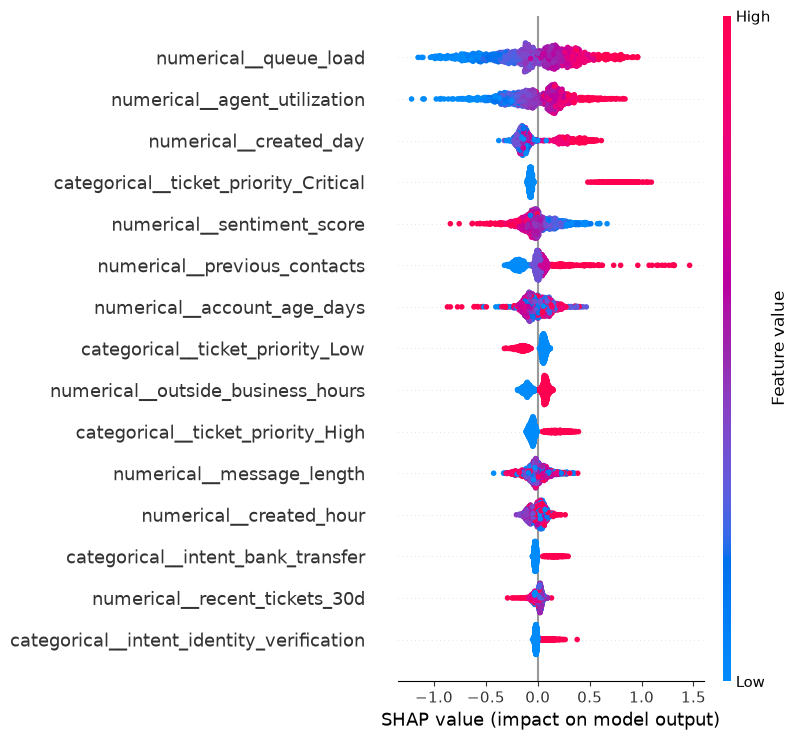

In [86]:
shap.summary_plot(
    shap_values.values,
    X_test_transformed_dense,
    feature_names=feature_names,
    max_display=15
)

Explain one high-risk ticket

In [87]:
highest_risk_position = np.argmax(
    test_probabilities
)

highest_risk_probability = (
    test_probabilities[
        highest_risk_position
    ]
)

print(
    "Highest predicted SLA risk:",
    f"{highest_risk_probability:.2%}"
)

Highest predicted SLA risk: 86.22%


In [88]:
high_risk_ticket = (
    X_test.iloc[
        highest_risk_position
    ]
)

high_risk_ticket

ticket_priority                   Critical
ticket_channel                         Web
customer_tier                      Premium
intent                    account_security
created_hour                             2
created_day                              0
is_weekend                               0
outside_business_hours                   1
previous_contacts                        1
recent_tickets_30d                       2
message_length                         232
sentiment_score                  -0.312203
queue_load                       86.456903
agent_utilization                 0.942519
account_age_days                      3142
Name: 3379, dtype: object

In [89]:
high_risk_shap = (
    shap_values.values[
        highest_risk_position
    ]
)

In [90]:
#create a readable table
local_explanation = pd.DataFrame({
    "feature":
        feature_names,

    "shap_value":
        high_risk_shap
})

In [91]:
#add absolute magnitude
local_explanation[
    "absolute_impact"
] = (
    local_explanation[
        "shap_value"
    ].abs()
)

In [92]:
#sort
local_explanation = (
    local_explanation
    .sort_values(
        "absolute_impact",
        ascending=False
    )
)

local_explanation.head(10)

,feature,shap_value,absolute_impact
0,categorical__ticket_priority_Critical,0.849634,0.849634
28,numerical__agent_utilization,0.788213,0.788213
27,numerical__queue_load,0.445378,0.445378
25,numerical__message_length,0.184270,0.184270
29,numerical__account_age_days,0.093111,0.093111
20,numerical__created_day,-0.082391,0.082391
11,categorical__intent_account_security,0.075354,0.075354
1,categorical__ticket_priority_High,-0.062825,0.062825
26,numerical__sentiment_score,0.051611,0.051611
2,categorical__ticket_priority_Low,0.051538,0.051538


Save SHAP importance

In [93]:
shap_importance.to_csv(
    "../ml/evaluation/"
    "sla_shap_feature_importance.csv",
    index=False
)

print(
    "SHAP feature importance saved!"
)

SHAP feature importance saved!


Create reusable SLA prediction function

In [94]:
FINAL_THRESHOLD = 0.25


def predict_sla_risk(
    ticket
):

    ticket_df = pd.DataFrame(
        [ticket]
    )

    probability = (
        final_xgb_model
        .predict_proba(
            ticket_df
        )[0, 1]
    )

    breach_alert = (
        probability
        >= FINAL_THRESHOLD
    )

    return {
        "sla_breach_probability":
            round(
                float(probability),
                4
            ),

        "sla_breach_percentage":
            round(
                float(probability)
                * 100,
                2
            ),

        "breach_alert":
            bool(
                breach_alert
            ),

        "decision_threshold":
            FINAL_THRESHOLD
    }

Test with a realistic ticket

In [95]:
sample_ticket = {
    "ticket_priority":
        "Critical",

    "ticket_channel":
        "Email",

    "customer_tier":
        "Standard",

    "intent":
        "account_security",

    "created_hour":
        22,

    "created_day":
        6,

    "is_weekend":
        1,

    "outside_business_hours":
        1,

    "previous_contacts":
        4,

    "recent_tickets_30d":
        5,

    "message_length":
        240,

    "sentiment_score":
        -0.85,

    "queue_load":
        92,

    "agent_utilization":
        0.94,

    "account_age_days":
        500
}

In [96]:
sample_prediction = (
    predict_sla_risk(
        sample_ticket
    )
)

sample_prediction

{'sla_breach_probability': 0.9669,
 'sla_breach_percentage': 96.69,
 'breach_alert': True,
 'decision_threshold': 0.25}

Save the final model

In [97]:
import joblib

from pathlib import Path


SLA_MODEL_PATH = Path(
    "../ml/artifacts/"
    "sla_risk_xgboost.joblib"
)


joblib.dump(
    {
        "model":
            final_xgb_model,

        "threshold":
            FINAL_THRESHOLD,

        "feature_columns":
            FEATURE_COLUMNS
    },
    SLA_MODEL_PATH
)


print(
    "Model saved:",
    SLA_MODEL_PATH
)

Model saved: ../ml/artifacts/sla_risk_xgboost.joblib


Save final evaluation results

In [98]:
final_sla_results = pd.DataFrame([
    {
        "model":
            "XGBoost",

        "dataset":
            "Final Test",

        "threshold":
            FINAL_THRESHOLD,

        "accuracy":
            test_accuracy,

        "precision":
            test_precision,

        "recall":
            test_recall,

        "f1":
            test_f1,

        "roc_auc":
            test_roc_auc,

        "pr_auc":
            test_pr_auc
    }
])


final_sla_results.to_csv(
    "../ml/evaluation/"
    "sla_final_test_results.csv",
    index=False
)

final_sla_results

,model,dataset,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,XGBoost,Final Test,0.25,0.536667,0.402252,0.779762,0.530722,0.66536,0.496545


Show the top local SHAP drivers

In [99]:
local_explanation.head(10)

,feature,shap_value,absolute_impact
0,categorical__ticket_priority_Critical,0.849634,0.849634
28,numerical__agent_utilization,0.788213,0.788213
27,numerical__queue_load,0.445378,0.445378
25,numerical__message_length,0.184270,0.184270
29,numerical__account_age_days,0.093111,0.093111
20,numerical__created_day,-0.082391,0.082391
11,categorical__intent_account_security,0.075354,0.075354
1,categorical__ticket_priority_High,-0.062825,0.062825
26,numerical__sentiment_score,0.051611,0.051611
2,categorical__ticket_priority_Low,0.051538,0.051538


In [100]:
top_local_drivers = (
    local_explanation
    .head(10)
    .copy()
)

top_local_drivers["effect"] = np.where(
    top_local_drivers["shap_value"] > 0,
    "Increases breach risk",
    "Decreases breach risk"
)

top_local_drivers[
    [
        "feature",
        "shap_value",
        "absolute_impact",
        "effect"
    ]
]

,feature,shap_value,absolute_impact,effect
0,categorical__ticket_priority_Critical,0.849634,0.849634,Increases breach risk
28,numerical__agent_utilization,0.788213,0.788213,Increases breach risk
27,numerical__queue_load,0.445378,0.445378,Increases breach risk
25,numerical__message_length,0.184270,0.184270,Increases breach risk
29,numerical__account_age_days,0.093111,0.093111,Increases breach risk
20,numerical__created_day,-0.082391,0.082391,Decreases breach risk
11,categorical__intent_account_security,0.075354,0.075354,Increases breach risk
1,categorical__ticket_priority_High,-0.062825,0.062825,Decreases breach risk
26,numerical__sentiment_score,0.051611,0.051611,Increases breach risk
2,categorical__ticket_priority_Low,0.051538,0.051538,Increases breach risk


In [101]:
top_local_drivers.to_csv(
    "../ml/evaluation/sla_high_risk_ticket_explanation.csv",
    index=False
)

Test the reusable risk function

In [102]:
sample_prediction = predict_sla_risk(
    sample_ticket
)

sample_prediction

{'sla_breach_probability': 0.9669,
 'sla_breach_percentage': 96.69,
 'breach_alert': True,
 'decision_threshold': 0.25}